In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Flatten, Dense, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report 

import warnings
warnings.filterwarnings("ignore")

print ('modules loaded')

modules loaded


In [22]:
data_dir='./content/Training/Alzheimer/Combined Dataset'
target_folder='train'
filepath=[]
labels=[]
all_folder_path = os.path.join(data_dir, target_folder)

if os.path.isdir(all_folder_path):
    filelist = os.listdir(all_folder_path)
    for f in filelist:
        fpath = os.path.join(all_folder_path, f)
        fipath=os.listdir(fpath)
        for image in fipath:
            path = os.path.join(fpath, image)
            filepath.append(path)
            labels.append(f)  

f_series = pd.Series(filepath, name='filepath')
l_series = pd.Series(labels, name='labels')
train_df = pd.concat([f_series, l_series], axis=1)

In [23]:
data_dir='./content/Training/Alzheimer/Combined Dataset'
target_folder='test'
filepath=[]
labels=[]
all_folder_path = os.path.join(data_dir, target_folder)

if os.path.isdir(all_folder_path):
    filelist = os.listdir(all_folder_path)
    for f in filelist:
        fpath = os.path.join(all_folder_path, f)
        fipath=os.listdir(fpath)
        for image in fipath:
            path = os.path.join(fpath, image)
            filepath.append(path)
            labels.append(f)  

f_series = pd.Series(filepath, name='filepath')
l_series = pd.Series(labels, name='labels')
test_df = pd.concat([f_series, l_series], axis=1)

In [24]:
train_df

,filepath,labels
0,./content/Training/Alzheimer/Combined Dataset\...,Mild Impairment
1,./content/Training/Alzheimer/Combined Dataset\...,Mild Impairment
2,./content/Training/Alzheimer/Combined Dataset\...,Mild Impairment
3,./content/Training/Alzheimer/Combined Dataset\...,Mild Impairment
4,./content/Training/Alzheimer/Combined Dataset\...,Mild Impairment
...,...,...
10235,./content/Training/Alzheimer/Combined Dataset\...,Very Mild Impairment
10236,./content/Training/Alzheimer/Combined Dataset\...,Very Mild Impairment
10237,./content/Training/Alzheimer/Combined Dataset\...,Very Mild Impairment
10238,./content/Training/Alzheimer/Combined Dataset\...,Very Mild Impairment


In [25]:
test_df

,filepath,labels
0,./content/Training/Alzheimer/Combined Dataset\...,Mild Impairment
1,./content/Training/Alzheimer/Combined Dataset\...,Mild Impairment
2,./content/Training/Alzheimer/Combined Dataset\...,Mild Impairment
3,./content/Training/Alzheimer/Combined Dataset\...,Mild Impairment
4,./content/Training/Alzheimer/Combined Dataset\...,Mild Impairment
...,...,...
1274,./content/Training/Alzheimer/Combined Dataset\...,Very Mild Impairment
1275,./content/Training/Alzheimer/Combined Dataset\...,Very Mild Impairment
1276,./content/Training/Alzheimer/Combined Dataset\...,Very Mild Impairment
1277,./content/Training/Alzheimer/Combined Dataset\...,Very Mild Impairment


In [26]:
count_train=train_df["labels"].value_counts()
count_train

labels
Mild Impairment         2560
Moderate Impairment     2560
No Impairment           2560
Very Mild Impairment    2560
Name: count, dtype: int64

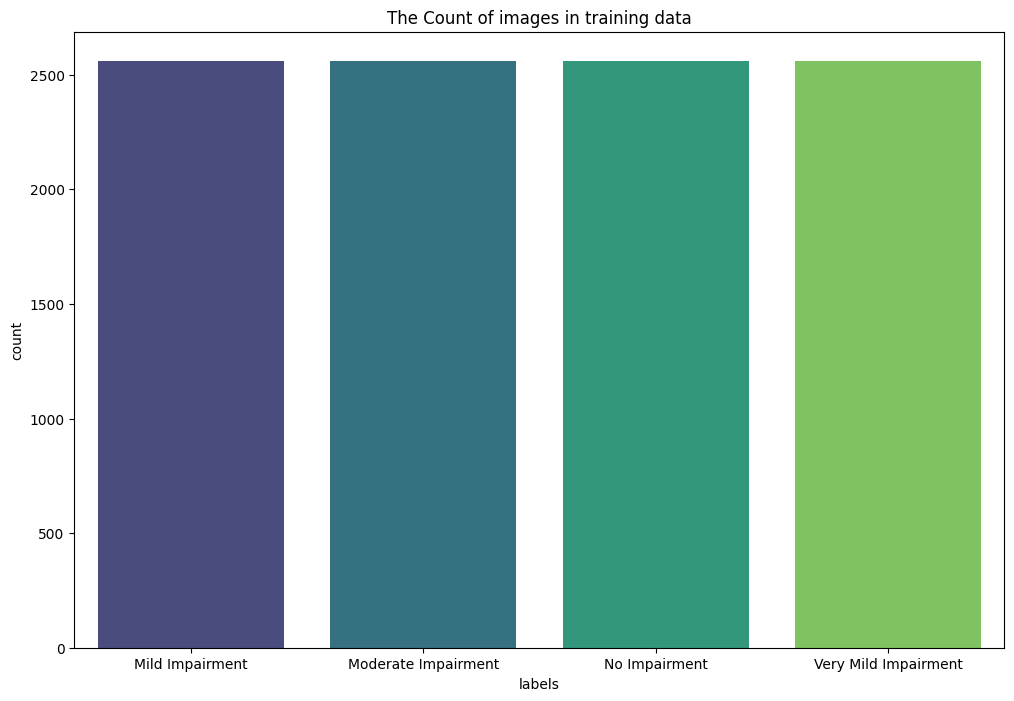

In [27]:
plt.figure(figsize=(12,8))
sns.barplot(x=count_train.index,y=count_train.values,palette='viridis')
plt.title('The Count of images in training data')
plt.xlabel('labels')
plt.ylabel('count')
plt.show()

In [28]:
count_test=test_df["labels"].value_counts()
count_test

labels
No Impairment           640
Very Mild Impairment    448
Mild Impairment         179
Moderate Impairment      12
Name: count, dtype: int64

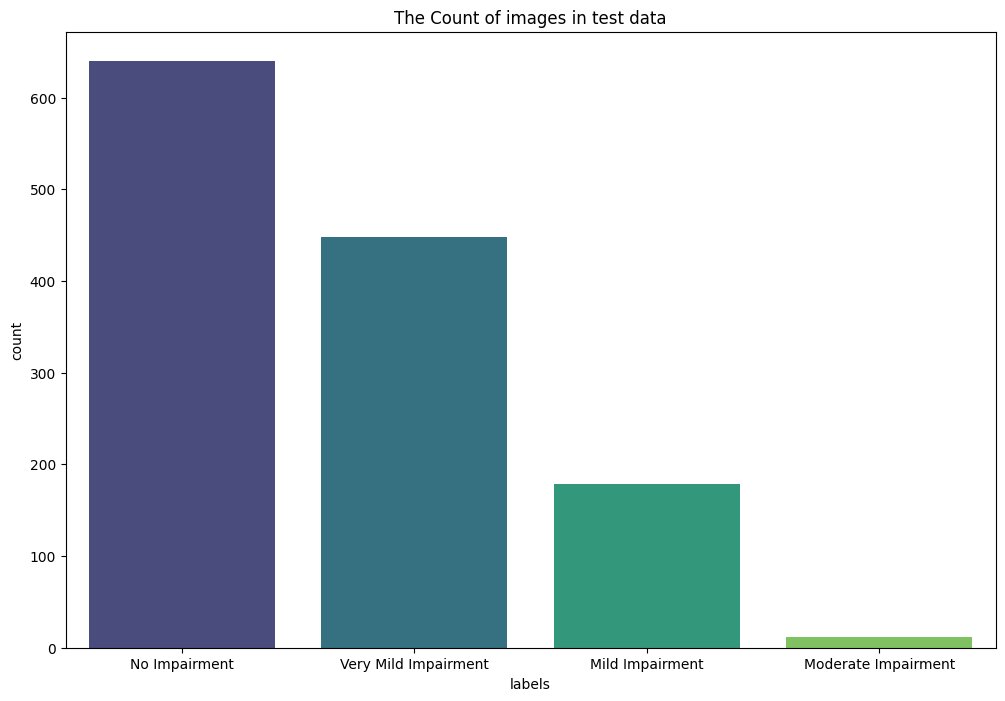

In [29]:
plt.figure(figsize=(12,8))
sns.barplot(x=count_test.index,y=count_test.values,palette='viridis')
plt.title('The Count of images in test data')
plt.xlabel('labels')
plt.ylabel('count')
plt.show()

In [30]:
strat=train_df['labels']
train_df,valid_df=train_test_split(train_df,test_size=0.2,random_state=42,stratify=strat)

In [31]:
print(train_df.shape)
print(valid_df.shape)

(8192, 2)
(2048, 2)


In [32]:
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
gen = ImageDataGenerator()

train_gen = gen.flow_from_dataframe( train_df, x_col= 'filepath', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = gen.flow_from_dataframe( valid_df, x_col= 'filepath', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                        color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = gen.flow_from_dataframe( test_df, x_col= 'filepath', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)

Found 8192 validated image filenames belonging to 4 classes.
Found 2048 validated image filenames belonging to 4 classes.
Found 1279 validated image filenames belonging to 4 classes.


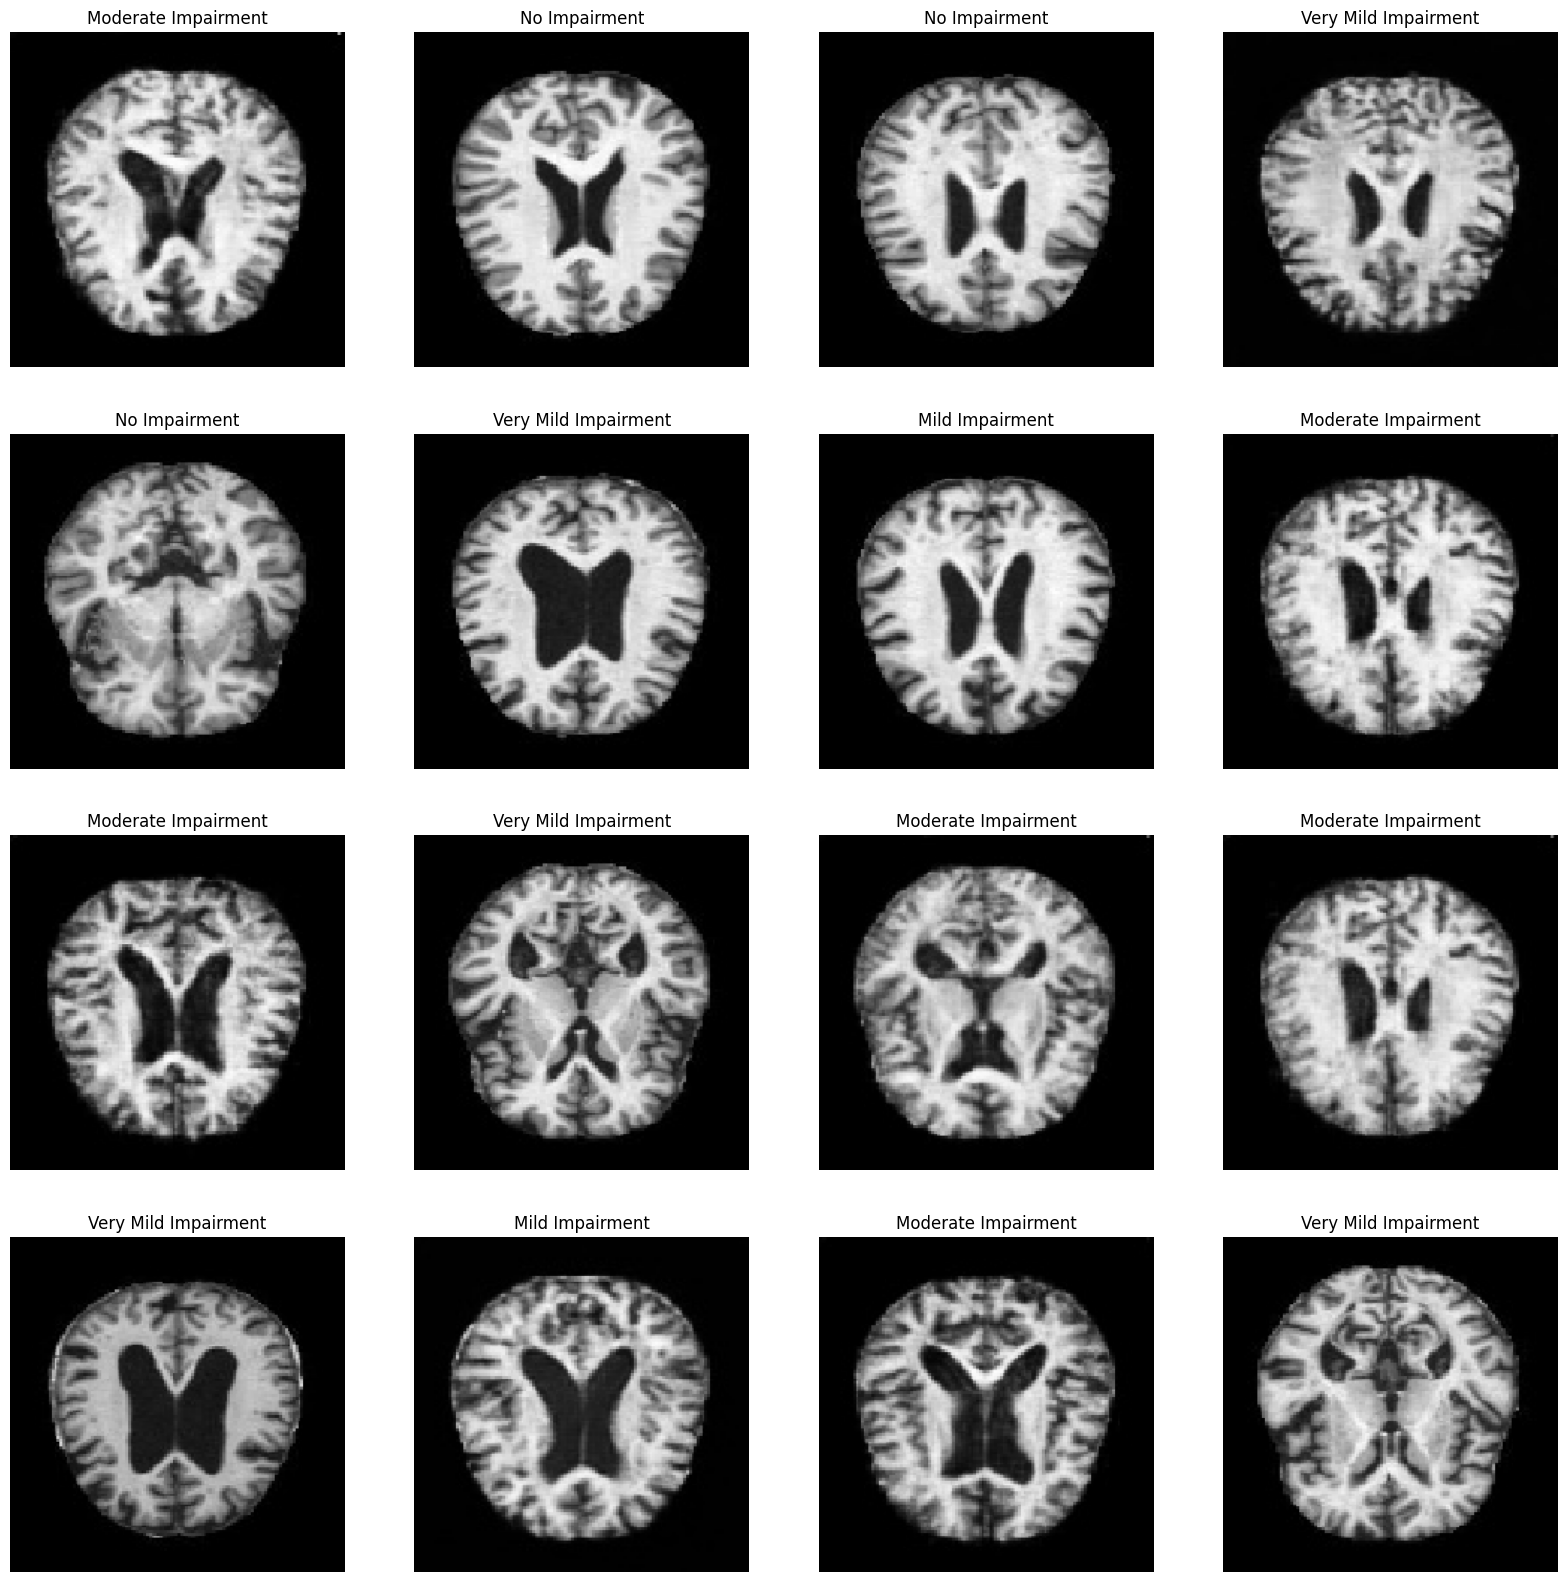

In [33]:
g_dict = train_gen.class_indices    
classes = list(g_dict.keys())      
images, labels = next(train_gen)     

plt.figure(figsize= (20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255      
    plt.imshow(image)
    index = np.argmax(labels[i])  
    class_name = classes[index]   
    plt.title(class_name, color= 'black', fontsize= 12)
    plt.axis('off')
plt.show()

In [34]:
base_model=keras.applications.EfficientNetV2B0(include_top=False,
    weights="imagenet",
    input_shape=(224,224,3))
model=Sequential([
    base_model,
    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.2),
    Dense(128,activation='relu'),
    Dense(4,activation='softmax')
])
model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 22s 1us/step


In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    16,056,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,009,300 (83.96 MB)

 Trainable params: 21,948,692 (83.73 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [36]:
early_stopping = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
history=model.fit(train_gen,epochs=100,validation_data=valid_gen,shuffle=False,
                  callbacks=[early_stopping],validation_steps= None)

Epoch 1/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 924s 2s/step - accuracy: 0.7123 - loss: 0.8462 - val_accuracy: 0.8706 - val_loss: 0.3229
Epoch 2/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 798s 2s/step - accuracy: 0.8829 - loss: 0.2782 - val_accuracy: 0.9312 - val_loss: 0.1695
Epoch 3/100
512/512 ━━━━━━━━━━━━━━━━━━━━ 723s 1s/step - accuracy: 0.9525 - loss: 0.1262 - val_accuracy: 0.9194 - val_loss: 0.2465
Epoch 4/100
118/512 ━━━━━━━━━━━━━━━━━━━━ 9:24 1s/step - accuracy: 0.9650 - loss: 0.0942

KeyboardInterrupt: 

In [ ]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')
plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [ ]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Valid Loss: ", valid_score[0])
print("Valid Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

In [ ]:
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

In [ ]:
plt.figure(figsize=(10,5))
cm=confusion_matrix(test_gen.classes,y_pred)
labels = list(test_gen.class_indices.keys())
sns.heatmap(cm,annot=True,fmt="d",xticklabels=labels,yticklabels=labels,cmap="Blues", linewidths=.5)
plt.xlabel('\nPredicted Label',fontsize=13)
plt.ylabel('Actual Label\n',fontsize=13);

In [ ]:
print(classification_report(test_gen.classes, y_pred, target_names= classes))

In [ ]:
model.save('model/updated_alzheimer_best_model.keras')